In [1]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import pip
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
import linearmodels as lm
from linearmodels import PanelOLS, RandomEffects
from scipy import stats
from linearmodels import RandomEffects
import statsmodels.api as sm
from linearmodels.panel import compare

In [2]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

      country  year  incidence  mortality           gdp       bmi    pop_65  \
0        fiji  2000  39.310026  33.722967   9426.113813  0.065177  3.437768   
1    cambodia  2000  11.807551  10.664151   1922.031791  0.035232  2.816518   
2    kiribati  2000  13.866566  12.601468   2481.415243  0.029855  3.413156   
3  kazakhstan  2000  35.284421  18.655098  12935.864368  0.094906  6.693366   
4     jamaica  2000  50.404926  25.599975   9518.231763  0.026733  6.060642   

   urban_pop  life_exp  fertility  labor_rate  internet  broadband  \
0     47.908    68.660      2.992      37.841  1.496850        NaN   
1     18.586    61.465      3.794      77.834  0.047023        NaN   
2     42.958    66.323      4.071         NaN  1.785230        NaN   
3     56.098    69.665      1.898      65.381  0.668594        NaN   
4     51.814    73.104      2.345      58.147  3.115780        NaN   

   health_exp  smoking  
0    3.424412     15.9  
1    6.482484     23.5  
2    7.773798     53.9  
3   

In [3]:
initial_countries=final_df['country'].nunique()
print(initial_countries)

171


In [4]:
initial_years=final_df['year'].nunique()
print(initial_years)

24


# OECD  Countries :

In [5]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'colombia', 'czechia', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovakia', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkiye', 'united kingdom', 'united states', 'costa rica']
print(len(oecd_countries))

38


# Creat Dummy Variables:

In [6]:
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# creat interaction :

is_oecd
0    3288
1     816
Name: count, dtype: int64


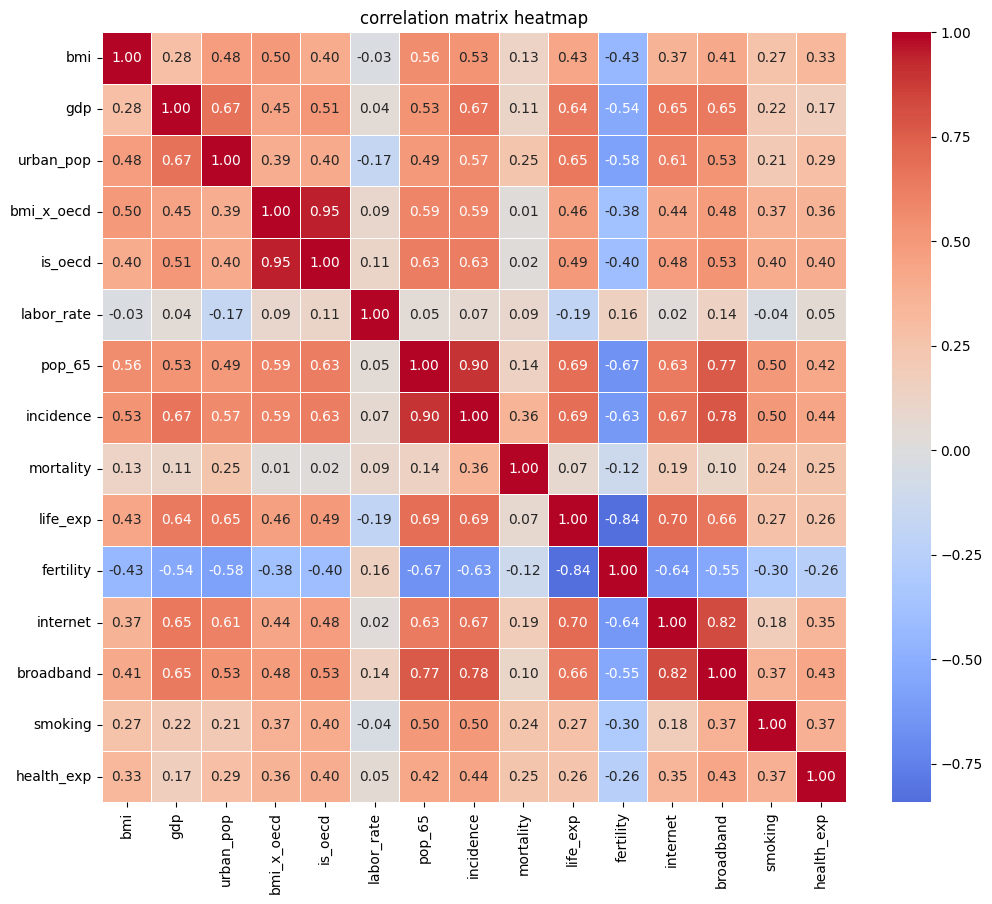

In [7]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())
columns_for_heatmap=['bmi', 'gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate', 'pop_65'
                      ,'incidence', 'mortality', 'life_exp', 'fertility','internet', 'broadband','smoking','health_exp']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()

# Dummy Variables: 

In [8]:
oecd_comparison= final_df.groupby('is_oecd').incidence.mean()
print(final_df['is_oecd'].value_counts())

is_oecd
0    3288
1     816
Name: count, dtype: int64


1. Aging Society Dummy: Based on WHO standards, societies with >10% population over 65 are considered "ageing" or "aged". This captures potential non-linear increases in cancer incidence due to population structure.

In [9]:
final_df['dm_high_aging_society'] = (final_df['pop_65'] > 10).astype(int)
print(final_df['dm_high_aging_society'].value_counts())

dm_high_aging_society
0    2762
1    1342
Name: count, dtype: int64


2. High Life Expectancy Dummy threshold of 75 years represents advanced healthcare systems and higher probability of disease detection.

In [10]:
final_df['dm_high_life_exp']=(final_df['life_exp']> 75).astype(int)
print(final_df['dm_high_life_exp'].value_counts())

dm_high_life_exp
1    2094
0    2010
Name: count, dtype: int64


In [11]:
comparison_mortal= final_df.groupby('dm_high_life_exp').mortality.mean()
print(comparison_mortal)

dm_high_life_exp
0    19.057082
1    19.670643
Name: mortality, dtype: float64


In [12]:
comparison_mortal= final_df.groupby('dm_high_life_exp').mortality.mean()
print(comparison_mortal)

dm_high_life_exp
0    19.057082
1    19.670643
Name: mortality, dtype: float64


In [13]:
print(final_df[['year', 'country', 'is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].head(100))

    year              country  is_oecd  dm_high_aging_society  \
0   2000                 fiji        0                      0   
1   2000             cambodia        0                      0   
2   2000             kiribati        0                      0   
3   2000           kazakhstan        0                      0   
4   2000              jamaica        0                      0   
..   ...                  ...      ...                    ...   
95  2000                spain        1                      1   
96  2000               cyprus        0                      0   
97  2000  antigua and barbuda        0                      0   
98  2001                malta        0                      1   
99  2001               canada        1                      1   

    dm_high_life_exp  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  
..               ...  
95                 1  
96                 1  
97          

# interaction of is_oecd variable and gdp

In [14]:
final_df['log_gdp']= np.log(final_df['gdp'])
final_df['log_gdp_is_oecd']= final_df['log_gdp']*final_df['is_oecd']
print(final_df['log_gdp_is_oecd'].head(5))

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: log_gdp_is_oecd, dtype: float64


In [15]:
final_df['is_oecd'] = 0
final_df.loc[final_df['country'].isin(oecd_countries), 'is_oecd'] = 1

# interaction of is_oecd variable and gdp
final_df['log_gdp'] = np.log(final_df['gdp'])
final_df['log_gdp_is_oecd'] = final_df['log_gdp'] * final_df['is_oecd']
# Filling NaNs in Interaction Term: Since 'NaN * 0 = NaN' in Python, rows where is_oecd is 0 but log_gdp is missing(NAN) 
# would incorrectly stay as NaN (and be counted in the results), then filled these with 0 to ensure only real OECD countries with data are counted.
final_df['log_gdp_is_oecd'] = final_df['log_gdp_is_oecd'].fillna(0)

# counting contries :
oecd_count = final_df[final_df['is_oecd'] == 1]['country'].nunique()
interaction_countries = final_df[final_df['log_gdp_is_oecd'] != 0]['country'].nunique()

In [16]:
#print(final_df[['year', 'country', 'gdp_is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
print(final_df[['country','gdp','is_oecd','log_gdp_is_oecd','dm_high_aging_society', 'dm_high_life_exp']].sample(15).round(2))

                  country        gdp  is_oecd  log_gdp_is_oecd  \
3968               monaco        NaN        0             0.00   
1957          afghanistan    2757.05        0             0.00   
894               comoros    2441.14        0             0.00   
1943              namibia   11266.61        0             0.00   
2476             thailand   18324.61        0             0.00   
2104  trinidad and tobago   36950.81        0             0.00   
2349         south africa   14182.33        0             0.00   
2270              ukraine   17889.09        0             0.00   
3692            australia   57450.38        1            10.96   
84             luxembourg  116258.43        1            11.66   
1690                 togo    1930.78        0             0.00   
611            mozambique     785.79        0             0.00   
1000         sierra leone    2379.94        0             0.00   
3677              grenada   16301.47        0             0.00   
778       

In [17]:
start_year=final_df['year'].min()
end_year=final_df['year'].max()
print(final_df[['year', 'country', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
start_count= final_df[final_df['year']== start_year]['dm_high_life_exp'].sum() 
end_count=final_df[final_df['year']== end_year]['dm_high_life_exp'].sum()
print(f"number of countries with high life_expectency in {start_count}")
print(f"number of countries with high life_expectency in {end_count}")

      year                   country  dm_high_aging_society  dm_high_life_exp
4004  2021                  zimbabwe                      0                 0
4005  2021  central african republic                      0                 0
4006  2021                   bahrain                      0                 1
4007  2021                madagascar                      0                 0
4008  2021                    malawi                      0                 0
...    ...                       ...                    ...               ...
4099  2023                    monaco                      1                 1
4100  2023                  dominica                      1                 0
4101  2023                 argentina                      1                 1
4102  2023        dominican republic                      0                 1
4103  2023                     nauru                      0                 0

[100 rows x 4 columns]
number of countries with high life_expec

# delet percentage of rows with missing value(NA):

In [18]:
missing_report = (final_df.isnull().sum() / len(final_df)) * 100
print(missing_report[missing_report > 0]) 

gdp            3.265107
labor_rate     8.260234
internet       4.556530
broadband     16.301170
health_exp     6.505848
smoking       15.204678
log_gdp        3.265107
dtype: float64


In [19]:
clean_df= final_df.dropna(subset=['mortality', 'gdp', 'pop_65', 'urban_pop', 'life_exp', 'fertility', 'labor_rate', 'log_gdp_is_oecd', 'internet', 'broadband', 'health_exp', 'smoking'])
print(f" Missing values after deleting NA in clean_df: {clean_df.isnull().sum()}")

 Missing values after deleting NA in clean_df: country                  0
year                     0
incidence                0
mortality                0
gdp                      0
bmi                      0
pop_65                   0
urban_pop                0
life_exp                 0
fertility                0
labor_rate               0
internet                 0
broadband                0
health_exp               0
smoking                  0
is_oecd                  0
bmi_x_oecd               0
dm_high_aging_society    0
dm_high_life_exp         0
log_gdp                  0
log_gdp_is_oecd          0
dtype: int64


# Building stepwise regression

# Step 1: Adding gdp and urbanisation:

In [20]:
df_step= clean_df.set_index(['country', 'year'])
exog_1_fe= sm.add_constant(df_step[['log_gdp', 'urban_pop']])
model_1_fe=PanelOLS(df_step['mortality'],exog_1_fe, entity_effects=True, time_effects=True).fit()
print(model_1_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1164
Estimator:                   PanelOLS   R-squared (Between):             -3.0288
No. Observations:                2691   R-squared (Within):              -0.0896
Date:                Mon, Mar 09 2026   R-squared (Overall):             -2.6038
Time:                        18:52:14   Log-likelihood                   -5801.9
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      166.54
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(2,2529)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             166.54
                            

# Step 2: Adding Pop_65:

In [21]:
exog_2_fe = df_step[['log_gdp', 'urban_pop', 'pop_65']]
model_2_fe = PanelOLS(df_step['mortality'], exog_2_fe, entity_effects=True, time_effects=True).fit()
print(model_2_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2480
Estimator:                   PanelOLS   R-squared (Between):              0.0508
No. Observations:                2691   R-squared (Within):               0.2300
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.0173
Time:                        18:52:14   Log-likelihood                   -5585.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      277.83
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(3,2528)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             277.83
                            

# Step 3: Adding Labor Rate:

In [22]:
exog_3_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate']])
model_3_fe=PanelOLS(df_step['mortality'], exog_3_fe, entity_effects=True, time_effects=True).fit()
print(model_3_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2713
Estimator:                   PanelOLS   R-squared (Between):             -2.0415
No. Observations:                2691   R-squared (Within):               0.2597
Date:                Mon, Mar 09 2026   R-squared (Overall):             -1.7901
Time:                        18:52:14   Log-likelihood                   -5542.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      235.26
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(4,2527)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             235.26
                            

# Step 4: Adding BMI:

In [23]:
exog_4_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi']])
model_4_fe=PanelOLS(df_step['mortality'], exog_4_fe, entity_effects=True, time_effects= True).fit()
print(model_4_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2828
Estimator:                   PanelOLS   R-squared (Between):             -1.9619
No. Observations:                2691   R-squared (Within):               0.2619
Date:                Mon, Mar 09 2026   R-squared (Overall):             -1.7015
Time:                        18:52:14   Log-likelihood                   -5521.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      199.23
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(5,2526)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             199.23
                            

# Step 5:Adding is_oecd as Dummy Variable:

In [24]:
exog_5_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd']])
model_5_fe=PanelOLS(df_step['mortality'], exog_5_fe, entity_effects=True, time_effects=True).fit()
print(model_5_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2918
Estimator:                   PanelOLS   R-squared (Between):             -10.114
No. Observations:                2691   R-squared (Within):               0.2734
Date:                Mon, Mar 09 2026   R-squared (Overall):             -9.9355
Time:                        18:52:14   Log-likelihood                   -5504.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      173.39
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(6,2525)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             173.39
                            

# Step 6: Adding High aging society as Dummy Variable:

In [25]:
exog_6_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society']])
model_6_fe = PanelOLS(df_step['mortality'], exog_6_fe, entity_effects=True, time_effects=True).fit()
print(model_6_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2989
Estimator:                   PanelOLS   R-squared (Between):             -10.225
No. Observations:                2691   R-squared (Within):               0.2815
Date:                Mon, Mar 09 2026   R-squared (Overall):             -10.041
Time:                        18:52:14   Log-likelihood                   -5490.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      153.76
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(7,2524)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             153.76
                            

# Step 7: Adding High life exp as Dummy Variable:

In [26]:
exog_7_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society','dm_high_life_exp']])
model_7_fe = PanelOLS(df_step['mortality'], exog_7_fe, entity_effects=True, time_effects= True).fit()
print(model_7_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2990
Estimator:                   PanelOLS   R-squared (Between):             -10.304
No. Observations:                2691   R-squared (Within):               0.2815
Date:                Mon, Mar 09 2026   R-squared (Overall):             -10.118
Time:                        18:52:14   Log-likelihood                   -5490.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      134.49
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(8,2523)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             134.49
                            

# create labor_rate * is_oecd variable:

In [27]:
df_step['labor_rate * is_oecd']= df_step['labor_rate']* df_step['is_oecd']

# Step 8: Adding labor_rate * is_oecd:

In [28]:
exog_8_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society',
                                     'dm_high_life_exp', 'labor_rate * is_oecd']])
model_8_fe = PanelOLS(df_step['mortality'], exog_8_fe, entity_effects=True, time_effects= True).fit()
print(model_8_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3001
Estimator:                   PanelOLS   R-squared (Between):             -9.3216
No. Observations:                2691   R-squared (Within):               0.2816
Date:                Mon, Mar 09 2026   R-squared (Overall):             -9.1514
Time:                        18:52:15   Log-likelihood                   -5488.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      120.18
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                  F(9,2522)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             120.18
                            

# Step 9: Adding internet:

In [29]:
exog_9_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet']])
model_9_fe = PanelOLS(df_step['mortality'], exog_9_fe, entity_effects=True, time_effects= True).fit()
print(model_9_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3087
Estimator:                   PanelOLS   R-squared (Between):             -9.3048
No. Observations:                2691   R-squared (Within):               0.2082
Date:                Mon, Mar 09 2026   R-squared (Overall):             -9.1503
Time:                        18:52:15   Log-likelihood                   -5471.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      112.56
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                 F(10,2521)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             112.56
                            

# Step  10: Adding broadband:

In [30]:
exog_10_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband']])
model_10_fe = PanelOLS(df_step['mortality'], exog_10_fe, entity_effects=True, time_effects= True).fit()
print(model_10_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4165
Estimator:                   PanelOLS   R-squared (Between):             -5.5297
No. Observations:                2691   R-squared (Within):               0.2506
Date:                Mon, Mar 09 2026   R-squared (Overall):             -5.4147
Time:                        18:52:15   Log-likelihood                   -5243.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      163.54
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                 F(11,2520)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             163.54
                            

# Step  11: Adding smoking:

In [31]:
exog_11_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet',
                                       'broadband','smoking']])
model_11_fe = PanelOLS(df_step['mortality'], exog_11_fe, entity_effects=True, time_effects= True).fit()
print(model_11_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4205
Estimator:                   PanelOLS   R-squared (Between):             -4.3533
No. Observations:                2691   R-squared (Within):               0.1600
Date:                Mon, Mar 09 2026   R-squared (Overall):             -4.2638
Time:                        18:52:15   Log-likelihood                   -5234.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      152.29
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                 F(12,2519)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             152.29
                            

# step 12: adding health_exp:

In [32]:
exog_12_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd','dm_high_aging_society',
                                      'dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband','smoking','health_exp']])
model_12_fe = PanelOLS(df_step['mortality'], exog_12_fe, entity_effects=True, time_effects= True).fit()
print(model_12_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4254
Estimator:                   PanelOLS   R-squared (Between):             -5.1031
No. Observations:                2691   R-squared (Within):               0.1264
Date:                Mon, Mar 09 2026   R-squared (Overall):             -5.0124
Time:                        18:52:15   Log-likelihood                   -5222.9
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      143.40
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.642   Distribution:                 F(13,2518)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             143.40
                            

# Comparing results of all Fixed Effect models:

In [33]:
Compare_results_fixed_Effect = compare({
    'FE model 1': model_1_fe,
    'FE model 2': model_2_fe,
    'FE model 3': model_3_fe,
    'FE model 4': model_4_fe,
    'FE model 5': model_5_fe,
    'FE model 6': model_6_fe,
    'FE model 7': model_7_fe,
    'FE model 8': model_8_fe,
    'FE model 9': model_9_fe,
    'FE model 10': model_10_fe,
    'FE model 11': model_11_fe,
    'FE model 12': model_12_fe })
print(Compare_results_fixed_Effect)

                                                                                               Model Comparison                                                                                              
                              FE model 1     FE model 2     FE model 3     FE model 4     FE model 5     FE model 6     FE model 7     FE model 8     FE model 9    FE model 10    FE model 11    FE model 12
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable                  mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality
Estimator                       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS 